# Notebook 02 — Modelo 1: LSTM apilada

**TFM · Máster en Inteligencia Artificial · Manuel Montilla Luna**

**Predicción de Vida Útil Restante (RUL) sobre NASA C-MAPSS**



El primer modelo de la comparativa es una LSTM apilada. Esta permitirá contrastar los resultados con la literatura y establece la
línea que los modelos posteriores (CNN-LSTM con atención y Transformer) deberán superar.

## 1. Configuración del entorno

In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

# Ajusta esta ruta si subes el proyecto a otra carpeta de tu Drive
PROJECT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/tfm")
DATA_DIR    = PROJECT_DIR / "data" / "CMAPSSData"
FIG_DIR     = PROJECT_DIR / "reports" / "figures"
MODELS_DIR  = PROJECT_DIR / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto : {PROJECT_DIR}")
print(f"Datos    : {DATA_DIR}   (existe: {DATA_DIR.exists()})")

Mounted at /content/drive
Proyecto : /content/drive/MyDrive/ColabNotebooks/tfm
Datos    : /content/drive/MyDrive/ColabNotebooks/tfm/data/CMAPSSData   (existe: True)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 23
np.random.seed(RANDOM_STATE)

import tensorflow as tf
import keras
from keras import layers

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU        : {gpus if gpus else 'NO DISPONIBLE — el entrenamiento será lento'}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Hiperparámetros del experimento

Se agrupan en una sola celda para que quede explícito qué se está variando en cada ejecución.

In [ ]:
SUBSET        = "FD001"   # subset de trabajo para las secciones 6 a 12
WINDOW        = 30        # longitud de la ventana deslizante, en ciclos
STRIDE        = 1         # desplazamiento entre ventanas consecutivas
RUL_CAP       = 125       # tope del RUL lineal a trozos
VAL_FRAC      = 0.20      # fracción de motores reservados para validación
EPOCHS        = 100
BATCH_SIZE    = 256
LEARNING_RATE = 1e-3

## 3. Esquema de datos y funciones de carga

Los ficheros de C-MAPSS son texto plano sin cabecera, con 26 columnas separadas por espacios.
Cada fila es un ciclo de operación (un vuelo completo) de una unidad de motor concreta.

In [ ]:
INDEX_COLS   = ["unit", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SUBSETS = ("FD001", "FD002", "FD003", "FD004")

N_CONDITIONS = {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}

N_FAULT_MODES = {"FD001": 1, "FD002": 1, "FD003": 2, "FD004": 2}

In [ ]:
@dataclass
class CMAPSSSubset:
    """Contenedor de un subset completo de C-MAPSS."""

    name: str
    train: pd.DataFrame
    test: pd.DataFrame
    rul_test: pd.Series

    @property
    def n_conditions(self):
        return N_CONDITIONS[self.name]

    @property
    def n_fault_modes(self):
        return N_FAULT_MODES[self.name]

    def summary(self):
        return pd.Series({
            "subset": self.name,
            "condiciones_operativas": self.n_conditions,
            "modos_de_fallo": self.n_fault_modes,
            "motores_train": self.train["unit"].nunique(),
            "motores_test": self.test["unit"].nunique(),
            "filas_train": len(self.train),
            "filas_test": len(self.test),
            "ciclos_min_train": int(self.train.groupby("unit")["cycle"].max().min()),
            "ciclos_max_train": int(self.train.groupby("unit")["cycle"].max().max()),
            "ciclos_medios_train": round(
                float(self.train.groupby("unit")["cycle"].max().mean()), 1),
        })

In [ ]:
def _read_cmapss_file(path):
    """
    Los ficheros originales terminan cada linea con dos espacios. Con `sep=" "` pandas generaria dos columnas fantasma llenas de
    NaN. Usando la expresion `\s+` como separador el problema desaparece.
    """

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"No se encuentra {path}. Descarga C-MAPSS y coloca los .txt ahi.")

    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")

    if df.shape[1] != len(ALL_COLS):
        raise ValueError(
            f"{path.name}: se esperaban {len(ALL_COLS)} columnas y se han leido "
            f"{df.shape[1]}. Revisa que el fichero no este corrupto.")

    df.columns = ALL_COLS
    return df.astype({"unit": "int32", "cycle": "int32"})


def _read_rul_file(path):
    """Lee RUL_FD00X.txt: una linea por motor de test con su RUL real."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    rul = pd.read_csv(path, sep=r"\s+", header=None, engine="python").iloc[:, 0]
    rul.name = "RUL"
    rul.index = range(1, len(rul) + 1)      # indexado por numero de unit (1-based)
    return rul.astype("int32")


def load_subset(name, data_dir=None):
    """Carga un subset completo: train + test + RUL de test."""
    name = name.upper()
    if name not in SUBSETS:
        raise ValueError(f"Subset desconocido: {name}. Opciones: {SUBSETS}")

    data_dir = Path(data_dir if data_dir is not None else DATA_DIR)
    return CMAPSSSubset(
        name=name,
        train=_read_cmapss_file(data_dir / f"train_{name}.txt"),
        test=_read_cmapss_file(data_dir / f"test_{name}.txt"),
        rul_test=_read_rul_file(data_dir / f"RUL_{name}.txt"),
    )


def load_all(data_dir=None):
    """Carga los cuatro subsets en un diccionario indexado por nombre."""
    return {name: load_subset(name, data_dir) for name in SUBSETS}


def describe_all(subsets):
    """Tabla descriptiva de los cuatro subsets."""
    return pd.DataFrame([s.summary() for s in subsets.values()]).set_index("subset")

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_643/3792326233.py:4: SyntaxWarning: invalid escape sequence '\s'
  NaN. Usando la expresion `\s+` como separador el problema desaparece.


## 4. Preprocesado

El pipeline se aplica en este orden:

1. Generación del target RUL con perfil lineal a trozos.
2. Identificación de los regímenes operativos mediante K-Means sobre las variables de ajuste.
3. Descarte de los sensores sin varianza informativa, evaluada dentro de cada régimen.
4. Normalización con un MinMaxScaler independiente por régimen, ajustado solo con train.
5. Generación de las ventanas deslizantes.
6. Separación de validación reservando motores completos, nunca filas sueltas.

### 4.1 Target RUL

In [ ]:
def add_rul_train(df, rul_cap=125):
    """
    Anade la columna RUL al conjunto de entrenamiento.

    En train cada motor se opera hasta el fallo, luego para un ciclo dado:
        RUL = ultimo_ciclo_del_motor - ciclo_actual

    Si `rul_cap` no es None se aplica RUL = min(RUL, rul_cap), obteniendo el
    perfil de degradacion lineal a trozos. La justificacion es que un motor
    nuevo no se degrada de forma apreciable: exigir al modelo que distinga
    entre 300 y 290 ciclos restantes no tiene reflejo fisico en los sensores.
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def add_rul_test(df, rul_test, rul_cap=125):
    """
    Anade la columna RUL al conjunto de test.

    En test las series estan truncadas antes del fallo. El fichero
    RUL_FD00X.txt indica cuantos ciclos le quedaban a cada motor tras su
    ultima observacion, de modo que:
        RUL(ciclo) = (ultimo_ciclo_observado - ciclo) + RUL_restante
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    remaining = df["unit"].map(rul_test)
    df["RUL"] = (max_cycle - df["cycle"]) + remaining
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df

### 4.2 Regímenes operativos y normalización

In [ ]:
def fit_regime_clusterer(train, n_conditions):
    """
    Ajusta un K-Means sobre las tres variables de ajuste operativo.

    En FD002 y FD004 las combinaciones (altitud, Mach, TRA) forman seis grupos
    perfectamente separados que corresponden a seis regimenes de vuelo. En
    FD001 y FD003 solo existe un regimen y el clustering no aporta nada.
    """
    if n_conditions <= 1:
        return None
    km = KMeans(n_clusters=n_conditions, random_state=RANDOM_STATE, n_init=10)
    km.fit(train[SETTING_COLS].values)
    return km


def assign_regime(df, clusterer):
    """Indice de regimen de cada fila (0 si solo hay un regimen)."""
    if clusterer is None:
        return np.zeros(len(df), dtype=int)
    return clusterer.predict(df[SETTING_COLS].values)


def fit_regime_scalers(train, regimes, feature_cols):
    """
    Ajusta un MinMaxScaler independiente para cada regimen operativo.

    Este es el paso clave del preprocesado en FD002/FD004: la varianza que
    introduce el regimen de vuelo es muy superior a la que introduce la
    degradacion, de modo que una normalizacion global enmascararia la senal
    util.
    """
    scalers = {}
    for r in np.unique(regimes):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train.loc[regimes == r, feature_cols].values)
        scalers[int(r)] = scaler
    return scalers


def apply_regime_scalers(df, regimes, scalers, feature_cols):
    """Aplica a cada fila el escalador correspondiente a su regimen."""
    df = df.copy()
    values = df[feature_cols].values.astype(np.float64)
    out = np.empty_like(values)
    for r, scaler in scalers.items():
        mask = regimes == r
        if mask.any():
            out[mask] = scaler.transform(values[mask])
    df[feature_cols] = out
    return df

### 4.3 Selección de variables

In [ ]:
def find_uninformative_sensors(train, regimes=None, threshold=1e-6):
    """
    Identifica sensores sin varianza informativa.

    En FD001 esto descarta 6 de los 21 sensores. Se detecta de forma empirica
    en lugar de codificar una lista fija, de modo que el criterio se adapta a
    cada subset.

    El calculo debe hacerse DENTRO de cada regimen operativo. En
    FD002 y FD004 varios sensores son constantes dentro de cada regimen de
    vuelo pero toman un valor distinto en cada uno. Medida globalmente su
    desviacion tipica es alta y pareceria que aportan informacion, cuando en
    realidad solo estan codificando el regimen, no el estado de degradacion.

    Criterio aplicado: se descarta un sensor si su desviacion tipica es
    despreciable en TODOS los regimenes (se toma el maximo entre regimenes).
    """
    if regimes is None:
        stds = train[SENSOR_COLS].std()
    else:
        per_regime = [train.loc[regimes == r, SENSOR_COLS].std()
                      for r in np.unique(regimes)]
        stds = pd.concat(per_regime, axis=1).max(axis=1)

    return sorted(stds[stds < threshold].index.tolist(),
                  key=lambda c: int(c.split("_")[1]))

### 4.4 Ventanas deslizantes y particiones

In [ ]:
def make_windows_train(df, feature_cols, window=30, stride=1):
    """
    Genera todas las ventanas deslizantes de un conjunto de entrenamiento.

    El target de cada ventana es el RUL del ULTIMO ciclo de la ventana, que es
    el instante desde el que se realiza la prediccion.

    Devuelve:
        X     : (n_ventanas, window, n_features)
        y     : (n_ventanas,)
        units : (n_ventanas,) motor de procedencia de cada ventana
    """
    X_list, y_list, unit_list = [], [], []

    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)
        target = group["RUL"].values.astype(np.float32)

        if len(group) < window:
            # Motor mas corto que la ventana: se descarta en train, donde hay
            # muestras de sobra. En test se aplica padding.
            continue

        for start in range(0, len(group) - window + 1, stride):
            end = start + window
            X_list.append(feats[start:end])
            y_list.append(target[end - 1])
            unit_list.append(unit)

    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def make_windows_test(df, feature_cols, window=30):
    """
    Genera UNA ventana por motor de test: la ultima disponible.

    Es el protocolo de evaluacion estandar de C-MAPSS. Se predice el RUL del
    motor en su ultimo ciclo observado y se compara con RUL_FD00X.txt.

    Motores con menos ciclos que la ventana: se aplica padding por repeticion
    del primer ciclo observado. Es preferible a descartarlos, porque en FD002 y
    FD004 hay motores de test muy cortos y descartarlos sesgaria la evaluacion
    hacia los casos faciles.
    """
    X_list, unit_list = [], []

    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)

        if len(feats) < window:
            pad = np.repeat(feats[:1], window - len(feats), axis=0)
            feats = np.vstack([pad, feats])

        X_list.append(feats[-window:])
        unit_list.append(unit)

    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def split_by_unit(X, y, units, val_frac=0.2):
    """
    Separa un conjunto de validacion reservando motores completos.

    Hacer el split por filas seria un error grave: ventanas consecutivas del
    mismo motor se solapan en `window - stride` ciclos, de modo que quedarian
    muestras casi identicas repartidas entre train y validacion y la metrica de
    validacion resultaria optimista.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    unique_units = np.unique(units)
    rng.shuffle(unique_units)

    n_val = max(1, int(round(len(unique_units) * val_frac)))
    val_units = set(unique_units[:n_val].tolist())

    val_mask = np.isin(units, list(val_units))
    return X[~val_mask], y[~val_mask], X[val_mask], y[val_mask]

### 4.5 Pipeline completo

In [ ]:
@dataclass
class PreparedData:
    """Resultado del pipeline completo, listo para alimentar a Keras."""

    subset: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    test_units: np.ndarray
    feature_cols: list
    dropped_sensors: list
    window: int = 30
    rul_cap: int = 125

    @property
    def n_features(self):
        return len(self.feature_cols)

    def report(self):
        return (
            f"[{self.subset}] ventana={self.window}  features={self.n_features}  "
            f"cap RUL={self.rul_cap}\n"
            f"  sensores descartados : {len(self.dropped_sensors)} "
            f"({', '.join(self.dropped_sensors) if self.dropped_sensors else 'ninguno'})\n"
            f"  X_train : {self.X_train.shape}\n"
            f"  X_val   : {self.X_val.shape}\n"
            f"  X_test  : {self.X_test.shape}")


def prepare(subset, window=30, stride=1, rul_cap=125, val_frac=0.2, use_settings=False):
    """
    Ejecuta el pipeline completo sobre un subset.

    use_settings: si es True incluye las tres variables de ajuste operativo
    como features adicionales. Tiene sentido en FD002/FD004, donde informan al
    modelo del regimen de vuelo. En FD001/FD003 son constantes.
    """
    train = add_rul_train(subset.train, rul_cap=rul_cap)
    test  = add_rul_test(subset.test, subset.rul_test, rul_cap=rul_cap)

    # Regimenes ANTES de la seleccion de variables, porque el criterio de
    # descarte de sensores debe evaluarse dentro de cada regimen.
    clusterer     = fit_regime_clusterer(train, subset.n_conditions)
    train_regimes = assign_regime(train, clusterer)
    test_regimes  = assign_regime(test, clusterer)

    dropped      = find_uninformative_sensors(train, regimes=train_regimes)
    sensor_cols  = [c for c in SENSOR_COLS if c not in dropped]
    feature_cols = sensor_cols + (SETTING_COLS if use_settings else [])

    # Escaladores ajustados SOLO con train, para evitar fuga de informacion
    scalers = fit_regime_scalers(train, train_regimes, feature_cols)
    train   = apply_regime_scalers(train, train_regimes, scalers, feature_cols)
    test    = apply_regime_scalers(test, test_regimes, scalers, feature_cols)

    X, y, units = make_windows_train(train, feature_cols, window=window, stride=stride)
    X_train, y_train, X_val, y_val = split_by_unit(X, y, units, val_frac=val_frac)

    X_test, test_units = make_windows_test(test, feature_cols, window=window)
    y_test = subset.rul_test.reindex(test_units).values.astype(np.float32)
    if rul_cap is not None:
        y_test = np.clip(y_test, None, rul_cap)

    return PreparedData(
        subset=subset.name, X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        test_units=test_units, feature_cols=feature_cols,
        dropped_sensors=dropped, window=window, rul_cap=rul_cap)

## 5. Métricas de evaluación

Además de RMSE y MAE se implementa la función de puntuación asimétrica definida por NASA para
el concurso PHM 2008, que es la métrica de referencia en la literatura de C-MAPSS.

Siendo d = RUL_predicho - RUL_real:

$$s_i = \begin{cases} e^{-d_i/13} - 1 & \text{si } d_i < 0 \\ e^{d_i/10} - 1 & \text{si } d_i \geq 0 \end{cases}$$

La función penaliza más la sobreestimación que la subestimación del RUL. Predecir que a un
motor le quedan más ciclos de los reales implica que la intervención de mantenimiento llega
tarde, con riesgo de fallo en servicio; subestimar solo implica una revisión anticipada, cuyo
coste es económico pero no de seguridad. Los denominadores 13 y 10 codifican esa asimetría.

A diferencia del RMSE, la puntuación no está normalizada por el número de muestras, de modo que
solo es comparable entre modelos evaluados sobre el mismo conjunto de test.

In [ ]:
def rmse(y_true, y_pred):
    """Raiz del error cuadratico medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def mae(y_true, y_pred):
    """Error absoluto medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.mean(np.abs(y_pred - y_true)))


def nasa_score(y_true, y_pred):
    """Funcion de puntuacion asimetrica de NASA (PHM 2008). Menor es mejor."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s))


def evaluate(y_true, y_pred, name="modelo"):
    """
    Bloque completo de metricas de un modelo.

    Incluye el porcentaje de predicciones retrasadas (d > 0), que es la lectura
    de negocio directa de la asimetria del NASA Score.
    """
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true

    return pd.Series({
        "modelo": name,
        "RMSE": round(rmse(y_true, y_pred), 3),
        "MAE": round(mae(y_true, y_pred), 3),
        "NASA_Score": round(nasa_score(y_true, y_pred), 1),
        "sesgo_medio": round(float(np.mean(d)), 3),
        "pct_retrasadas": round(float(np.mean(d > 0) * 100), 1),
    })


def comparison_table(results):
    """Tabla comparativa final ordenada por RMSE."""
    return pd.DataFrame(results).set_index("modelo").sort_values("RMSE")

## 6. Ejecución del pipeline

In [ ]:
subset = load_subset(SUBSET, DATA_DIR)
print(subset.summary().to_string())

subset                    FD001
condiciones_operativas        1
modos_de_fallo                1
motores_train               100
motores_test                100
filas_train               20631
filas_test                13096
ciclos_min_train            128
ciclos_max_train            362
ciclos_medios_train       206.3


In [ ]:
data = prepare(
    subset,
    window=WINDOW,
    stride=STRIDE,
    rul_cap=RUL_CAP,
    val_frac=VAL_FRAC,
    use_settings=subset.n_conditions > 1,  # los settings solo informan si hay varios regímenes
)
print(data.report())

[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6 (sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19)
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)


## 7. Inspección de los tensores

Comprobación de que los datos tienen la forma esperada antes de entrenar. Este es el punto
donde se detectan la mayoría de los errores de preprocesado.

In [ ]:
print(f"X_train : {data.X_train.shape}   (ventanas, ciclos, sensores)")
print(f"y_train : {data.y_train.shape}")
print(f"X_val   : {data.X_val.shape}")
print(f"X_test  : {data.X_test.shape}   -> una ventana por motor de test")
print()
print(f"Features utilizadas ({data.n_features}): {', '.join(data.feature_cols)}")
print()
print(f"Rango de X_train : [{data.X_train.min():.3f}, {data.X_train.max():.3f}]  (debe estar en [0, 1])")
print(f"Rango de y_train : [{data.y_train.min():.1f}, {data.y_train.max():.1f}]  (debe topar en {RUL_CAP})")
print(f"NaN en X_train   : {np.isnan(data.X_train).sum()}  (debe ser 0)")

X_train : (14381, 30, 15)   (ventanas, ciclos, sensores)
y_train : (14381,)
X_val   : (3350, 30, 15)
X_test  : (100, 30, 15)   -> una ventana por motor de test

Features utilizadas (15): sensor_2, sensor_3, sensor_4, sensor_6, sensor_7, sensor_8, sensor_9, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_17, sensor_20, sensor_21

Rango de X_train : [0.000, 1.000]  (debe estar en [0, 1])
Rango de y_train : [0.0, 125.0]  (debe topar en 125)
NaN en X_train   : 0  (debe ser 0)


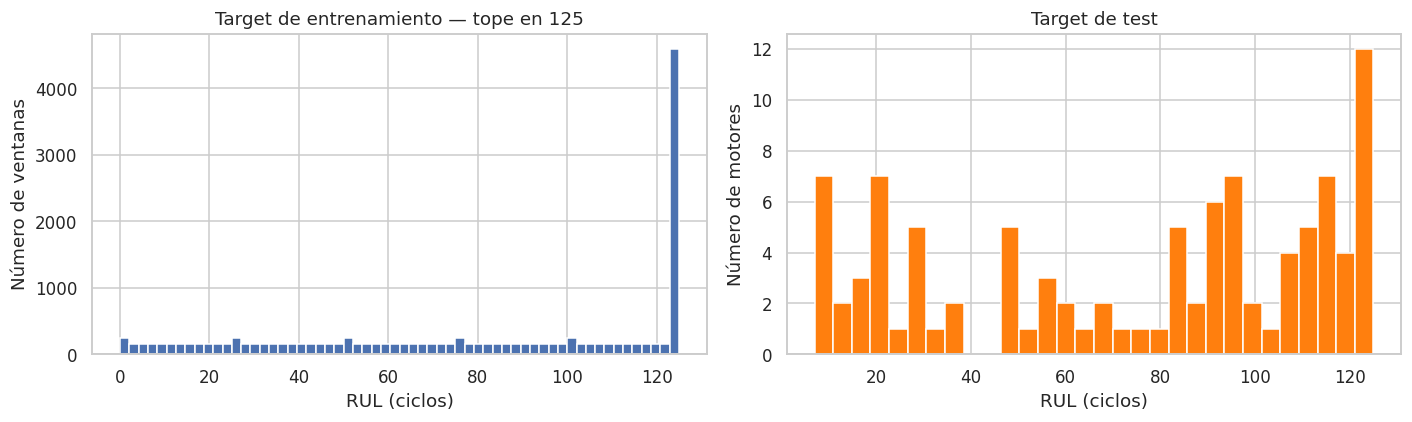

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(data.y_train, bins=60, edgecolor="white")
axes[0].set_xlabel("RUL (ciclos)"); axes[0].set_ylabel("Número de ventanas")
axes[0].set_title(f"Target de entrenamiento — tope en {RUL_CAP}")

axes[1].hist(data.y_test, bins=30, edgecolor="white", color="tab:orange")
axes[1].set_xlabel("RUL (ciclos)"); axes[1].set_ylabel("Número de motores")
axes[1].set_title("Target de test")

fig.tight_layout()
plt.show()

La acumulación en el valor máximo es el efecto esperado del tope: todas las ventanas
correspondientes a la fase inicial de vida del motor comparten el mismo target.

## 8. Arquitectura del modelo

```
Input (WINDOW, n_features)
   ↓
LSTM(100, return_sequences=True)   → devuelve la secuencia completa
Dropout(0.2)
   ↓
LSTM(50)                           → resume la ventana en un vector
Dropout(0.2)
   ↓
Dense(50, relu)
Dense(1)                           → RUL estimado
```


In [ ]:
def build_lstm(window, n_features, units=(100, 50), dropout=0.2,
               dense_units=50, learning_rate=1e-3, seed=RANDOM_STATE,
               name="lstm_apilada"):
    """LSTM apilada de dos capas recurrentes."""
    keras.utils.set_random_seed(seed)

    inputs = keras.Input(shape=(window, n_features), name="ventana_sensores")

    x = layers.LSTM(units[0], return_sequences=True, name="lstm_1")(inputs)
    x = layers.Dropout(dropout, name="dropout_1")(x)

    x = layers.LSTM(units[1], return_sequences=False, name="lstm_2")(x)
    x = layers.Dropout(dropout, name="dropout_2")(x)

    x = layers.Dense(dense_units, activation="relu", name="dense_oculta")(x)
    outputs = layers.Dense(1, name="rul")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
    return model


def default_callbacks(checkpoint_path=None, patience=15, reduce_lr_patience=7):
    """
    Callbacks usados en todos los entrenamientos.

    - EarlyStopping con restore_best_weights: evita el sobreajuste y garantiza
      que el modelo evaluado sea el de mejor validacion, no el de la ultima epoca.
    - ReduceLROnPlateau: reduce el learning rate cuando la validacion se estanca.
    - ModelCheckpoint: persiste el mejor modelo en formato .keras, el formato
      nativo actual (el antiguo .h5 sigue soportado pero ya no es el recomendado).
    """
    cbs = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=reduce_lr_patience,
            min_lr=1e-5, verbose=1),
    ]
    if checkpoint_path:
        cbs.append(keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0))
    return cbs

In [ ]:
model = build_lstm(
    window=data.window,
    n_features=data.n_features,
    units=(100, 50),
    dropout=0.2,
    dense_units=50,
    learning_rate=LEARNING_RATE,
)
model.summary()

Model: "lstm_apilada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ventana_sensores (InputLayer)   │ (None, 30, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 100)        │        46,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_oculta (Dense)            │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul (Dense)                     │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,201 (309.38 KB)

 Trainable params: 79,201 (309.38 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Entrenamiento

In [ ]:
ckpt = MODELS_DIR / f"lstm_{SUBSET}.keras"

history = model.fit(
    data.X_train, data.y_train / RUL_CAP,          # ← escalado
    validation_data=(data.X_val, data.y_val / RUL_CAP),   # ← escalado
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=default_callbacks(checkpoint_path=str(ckpt)),
    verbose=1,
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0665 - mae: 0.1979 - rmse: 0.2578 - val_loss: 0.0376 - val_mae: 0.1599 - val_rmse: 0.1938 - learning_rate: 0.0010
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0300 - mae: 0.1363 - rmse: 0.1732 - val_loss: 0.0313 - val_mae: 0.1429 - val_rmse: 0.1770 - learning_rate: 0.0010
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0233 - mae: 0.1197 - rmse: 0.1528 - val_loss: 0.0236 - val_mae: 0.1225 - val_rmse: 0.1535 - learning_rate: 0.0010
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0189 - mae: 0.1077 - rmse: 0.1373 - val_loss: 0.0227 - val_mae: 0.1172 - val_rmse: 0.1507 - learning_rate: 0.0010
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0164 - mae: 0.0993 - rmse: 0.1280 - val_loss: 0.0218 - val_mae: 0.1130 - val_rmse: 0.1477 - learning_rate: 0.0010
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0152 - mae: 0.0950 - rmse: 0.1234 - val_loss: 0.0207 - val

## 10. Curvas de aprendizaje

Diagnóstico de convergencia y sobreajuste. Si la curva de validación sube mientras la de
entrenamiento sigue bajando, hay sobreajuste; si ambas se estancan, el modelo no tiene
capacidad suficiente o el learning rate es inadecuado.

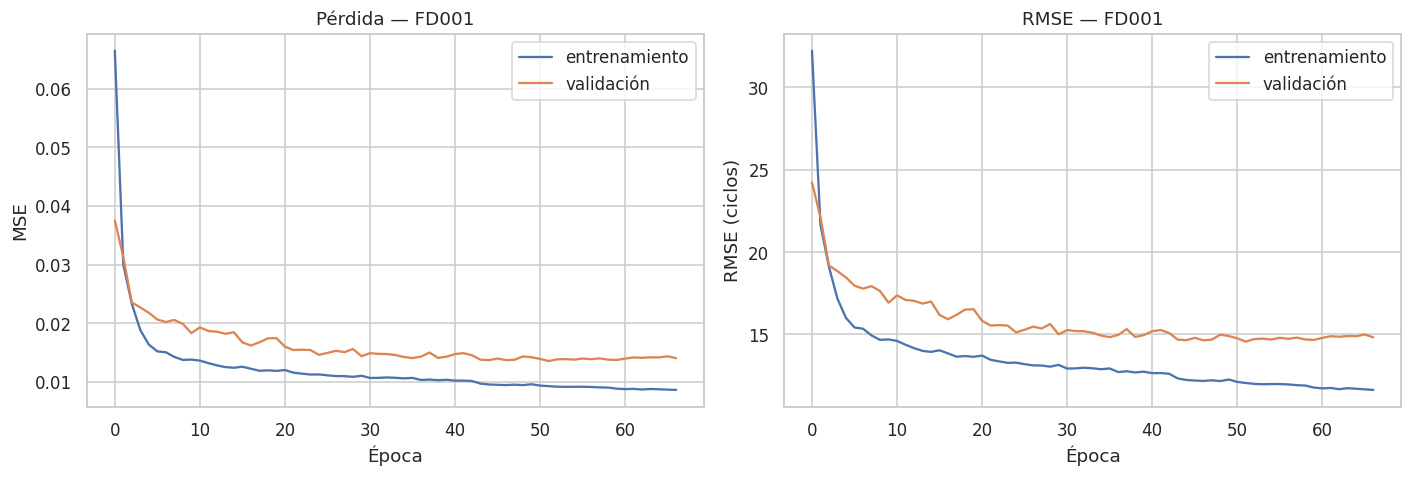

Épocas ejecutadas : 67
Mejor val_RMSE    : 0.117 ciclos


In [ ]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(h["loss"], label="entrenamiento")
axes[0].plot(h["val_loss"], label="validación")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE")
axes[0].set_title(f"Pérdida — {SUBSET}"); axes[0].legend()

axes[1].plot(np.array(h["rmse"]) * RUL_CAP, label="entrenamiento")
axes[1].plot(np.array(h["val_rmse"]) * RUL_CAP, label="validación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("RMSE (ciclos)")
axes[1].set_title(f"RMSE — {SUBSET}"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / f"curvas_aprendizaje_lstm_{SUBSET}.png", bbox_inches="tight")
plt.show()

print(f"Épocas ejecutadas : {len(h['loss'])}")
print(f"Mejor val_RMSE    : {min(h['val_rmse']):.3f} ciclos")

## 11. Evaluación sobre el conjunto de test

El protocolo estándar de C-MAPSS evalúa una única predicción por motor de test: la
correspondiente a su último ciclo observado, comparada con el valor de RUL_FD00X.txt.

In [ ]:
y_pred = model.predict(data.X_test, verbose=0).ravel() * RUL_CAP   # ← desescalado
y_pred = np.clip(y_pred, 0, RUL_CAP)   # el RUL no puede ser negativo ni superar el tope

resultado = evaluate(data.y_test, y_pred, name=f"LSTM_{SUBSET}")
print(resultado.to_string())

modelo            LSTM_FD001
RMSE                   13.87
MAE                   10.216
NASA_Score             360.2
sesgo_medio            2.448
pct_retrasadas          65.0


### Interpretación de referencia

Valores publicados en la literatura para FD001, como orden de magnitud:

| Enfoque | RMSE |
|---|---|
| MLP | ~37 |
| SVR | ~21 |
| CNN | ~18 |
| LSTM | ~16 |
| BiLSTM | ~14 |
| CNN profunda | ~12,6 |
| Arquitecturas con atención | ~11,5–12 |

## 12. Diagnóstico visual de las predicciones

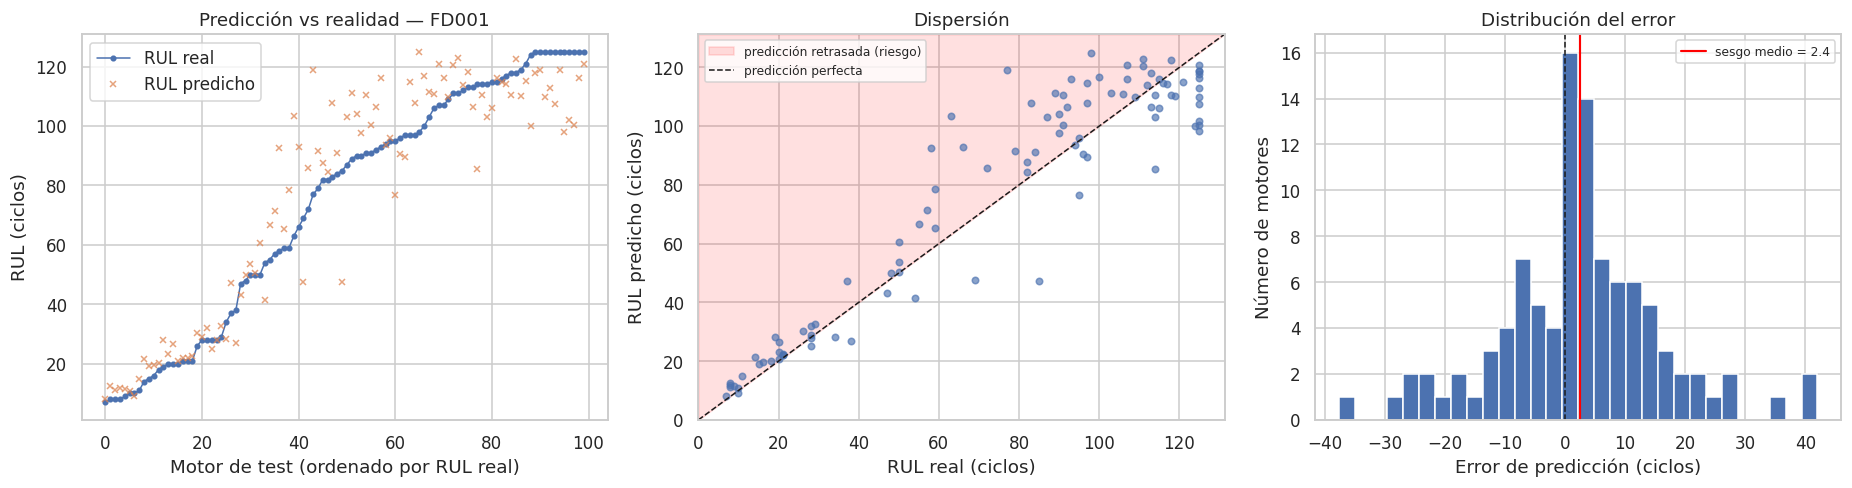

In [ ]:
y_true = data.y_test
err = y_pred - y_true
order = np.argsort(y_true)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

axes[0].plot(y_true[order], "o-", ms=3, lw=1, label="RUL real")
axes[0].plot(y_pred[order], "x", ms=4, alpha=0.75, label="RUL predicho")
axes[0].set_xlabel("Motor de test (ordenado por RUL real)")
axes[0].set_ylabel("RUL (ciclos)")
axes[0].set_title(f"Predicción vs realidad — {SUBSET}"); axes[0].legend()

lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
axes[1].fill_between(lim, lim, lim[1], alpha=0.12, color="red",
                     label="predicción retrasada (riesgo)")
axes[1].scatter(y_true, y_pred, s=18, alpha=0.65)
axes[1].plot(lim, lim, "k--", lw=1, label="predicción perfecta")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("RUL real (ciclos)"); axes[1].set_ylabel("RUL predicho (ciclos)")
axes[1].set_title("Dispersión"); axes[1].legend(fontsize=8)

axes[2].hist(err, bins=30, edgecolor="white")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].axvline(err.mean(), color="red", lw=1.4, label=f"sesgo medio = {err.mean():.1f}")
axes[2].set_xlabel("Error de predicción (ciclos)")
axes[2].set_ylabel("Número de motores")
axes[2].set_title("Distribución del error"); axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / f"predicciones_lstm_{SUBSET}.png", bbox_inches="tight")
plt.show()

El panel central es el más relevante para la lectura de negocio: los puntos que caen en la
región sombreada corresponden a motores cuyo RUL se ha sobreestimado, es decir, aquellos en
los que el mantenimiento se planificaría demasiado tarde.

## 13. Entrenamiento sobre los cuatro subsets

La comparación entre subsets es lo que permite atribuir la pérdida de rendimiento a una causa
concreta:

- FD001 → FD002 aísla el efecto de la variabilidad operativa (1 → 6 regímenes).
- FD001 → FD003 aísla el efecto de la multiplicidad de fallos (1 → 2 modos).
- FD004 combina ambos factores.

In [ ]:
TODOS = ["FD001", "FD002", "FD003", "FD004"]
resultados, historiales = [], {}

for nombre in TODOS:
    print(f"\n{'='*70}\n  {nombre}\n{'='*70}")
    s = load_subset(nombre, DATA_DIR)
    d = prepare(s, window=WINDOW, stride=STRIDE, rul_cap=RUL_CAP,
                val_frac=VAL_FRAC, use_settings=s.n_conditions > 1)
    print(d.report())

    m = build_lstm(window=d.window, n_features=d.n_features,
                   learning_rate=LEARNING_RATE)
    hist = m.fit(
        d.X_train, d.y_train / RUL_CAP,                  # ← escalado
        validation_data=(d.X_val, d.y_val / RUL_CAP),    # ← escalado
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=default_callbacks(
            checkpoint_path=str(MODELS_DIR / f"lstm_{nombre}.keras")),
        verbose=0,
    )
    p = np.clip(m.predict(d.X_test, verbose=0).ravel() * RUL_CAP, 0, RUL_CAP)
    r = evaluate(d.y_test, p, name=f"LSTM_{nombre}")
    print(r.to_string())

    resultados.append(r)
    historiales[nombre] = hist.history

tabla = comparison_table(resultados)
(PROJECT_DIR / "reports").mkdir(parents=True, exist_ok=True)
tabla.to_csv(PROJECT_DIR / "reports" / "resultados_lstm.csv")
tabla


  FD001
[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6 (sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19)
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 59: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 66: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 52.
modelo            LSTM_FD001
RMSE                  13.923
MAE                   10.299
NASA_Score             362.5
sesgo_medio            2.536
pct_retrasadas          66.0

  FD002
[FD002] ventana=30  features=20  cap RUL=125
  sensores descartados : 4 (sensor_1, sensor_5, sensor_18, sensor_19)
  X_train : (36545, 30, 20)
  X_val   : (9674, 30, 20)
  X_test  : (259, 30, 20

,RMSE,MAE,NASA_Score,sesgo_medio,pct_retrasadas
modelo,,,,,
LSTM_FD003,13.423,9.653,372.7,4.145,56.0
LSTM_FD001,13.923,10.299,362.5,2.536,66.0
LSTM_FD002,14.434,10.634,1115.3,1.777,55.2
LSTM_FD004,15.425,11.226,1379.2,1.508,48.4


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

tabla["RMSE"].plot(kind="bar", ax=axes[0], color="tab:blue", edgecolor="black")
axes[0].set_ylabel("RMSE (ciclos)"); axes[0].set_title("RMSE por subset")
axes[0].tick_params(axis="x", rotation=45)

tabla["NASA_Score"].plot(kind="bar", ax=axes[1], color="tab:orange", edgecolor="black")
axes[1].set_ylabel("NASA Score")
axes[1].set_title("Puntuación NASA por subset (menor es mejor)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparativa_subsets_lstm.png", bbox_inches="tight")
plt.show()

## 14. Robustez frente a la semilla aleatoria

FD001 tiene solo 100 motores de test, cada uno con una única predicción. Con una muestra tan
pequeña el RMSE presenta una varianza de muestreo apreciable: cambiar la semilla puede moverlo
en torno a un punto sin que nada esté mal.

Entrenar con varias semillas y reportar media ± desviación típica evita concluir que un
modelo supera a otro cuando la diferencia es ruido. Es la forma metodológicamente correcta de
presentar la comparativa final.

In [ ]:
SEMILLAS = [23, 7, 2024]
repeticiones = []

for semilla in SEMILLAS:
    m = build_lstm(window=data.window, n_features=data.n_features,
                   learning_rate=LEARNING_RATE, seed=semilla)
    m.fit(data.X_train, data.y_train / RUL_CAP,
          validation_data=(data.X_val, data.y_val / RUL_CAP),
          epochs=EPOCHS, batch_size=BATCH_SIZE,
          callbacks=default_callbacks(), verbose=0)
    p = np.clip(m.predict(data.X_test, verbose=0).ravel() * RUL_CAP, 0, RUL_CAP)
    r = evaluate(data.y_test, p, name=f"semilla_{semilla}")
    repeticiones.append(r)
    print(f"semilla {semilla:>5} -> RMSE {r['RMSE']:.3f}   NASA {r['NASA_Score']:.1f}")

rep = pd.DataFrame(repeticiones).set_index("modelo")
print(f"\nRMSE       : {rep['RMSE'].mean():.2f} ± {rep['RMSE'].std():.2f}")
print(f"NASA Score : {rep['NASA_Score'].mean():.1f} ± {rep['NASA_Score'].std():.1f}")


Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 59: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 66: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 52.
semilla    23 -> RMSE 13.943   NASA 379.8

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 63: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 70: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 77: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 84: ReduceLROnPlateau reducing learning rate to 1e-05.
Epoch 91: early stopping
Restori

semilla     7 -> RMSE 13.645   NASA 323.6

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 53: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 60: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 63: early stopping
Restoring model weights from the end of the best epoch: 48.
semilla  2024 -> RMSE 13.994   NASA 361.0

RMSE       : 13.86 ± 0.19
NASA Score : 354.8 ± 28.6
